<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_04_Deep_Learning/Week_03_ANN_Performance_Improving_Methods/Day_03_L2_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### By multiple attempts and conclusions: L2 is musch better than L1 in D.L.(also L1L2 can be used in some situations)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [21]:
import tensorflow

In [4]:
from sklearn.datasets import make_moons

In [5]:
x, y = make_moons(100, noise = 0.2, random_state = 42)

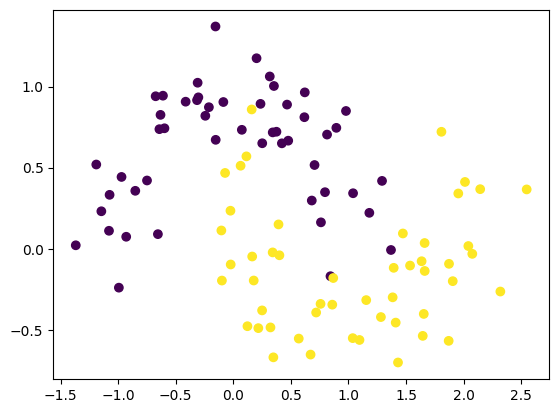

In [6]:
plt.scatter(x = x[:,0], y= x[:,1], c = y)
plt.show()

In [9]:
model1 = Sequential()

model1.add(Dense(128, input_dim = 2, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))
adam = Adam(learning_rate = 0.001)
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [11]:
history1 = model1.fit(x, y, epochs= 300, validation_split= 0.2, verbose=1)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6375 - loss: 0.6668 - val_accuracy: 0.8000 - val_loss: 0.6424
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8875 - loss: 0.6060 - val_accuracy: 0.8000 - val_loss: 0.5960
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8750 - loss: 0.5560 - val_accuracy: 0.8000 - val_loss: 0.5598
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8750 - loss: 0.5137 - val_accuracy: 0.8000 - val_loss: 0.5297
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8750 - loss: 0.4766 - val_accuracy: 0.8000 - val_loss: 0.5041
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8750 - loss: 0.4446 - val_accuracy: 0.8000 - val_loss: 0.4825
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8750 - loss: 0.4142 - val_accuracy: 0.8000 - val_loss: 0.4636
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8750 - loss: 0.3873 - val_accuracy: 0.8000 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


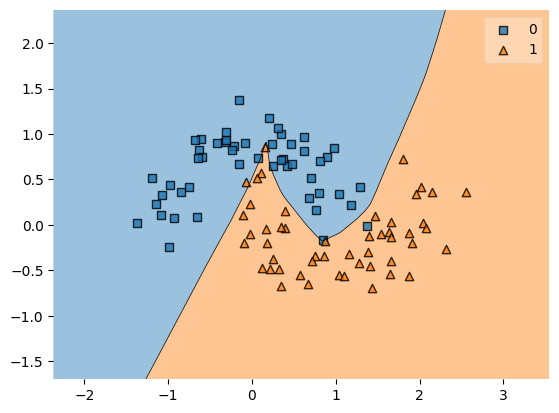

In [13]:
plot_decision_regions(x, y, clf=model1)
plt.show()

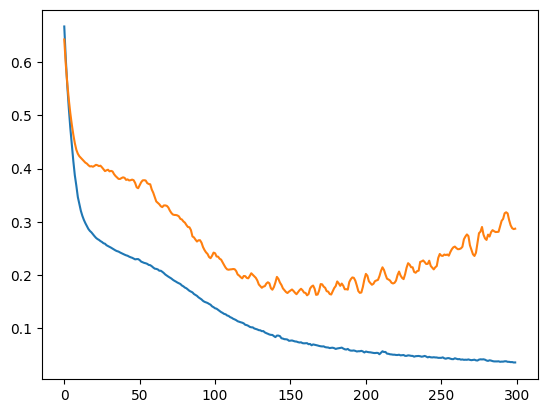

In [14]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.show()

In [26]:
model2 = Sequential()

model2.add(Dense(128, input_dim = 2, activation='relu', kernel_regularizer= tensorflow.keras.regularizers.L2(0.03)))
model2.add(Dense(128, activation='relu', kernel_regularizer= tensorflow.keras.regularizers.L2(0.03)))
model2.add(Dense(1, activation='sigmoid'))
adam = Adam(learning_rate = 0.001)
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [30]:
history2 = model2.fit(x, y, epochs = 300, validation_split= 0.2, verbose=1)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8750 - loss: 0.3472 - val_accuracy: 0.8000 - val_loss: 0.4423
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8750 - loss: 0.3451 - val_accuracy: 0.8000 - val_loss: 0.4439
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8750 - loss: 0.3482 - val_accuracy: 0.8000 - val_loss: 0.4458
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8750 - loss: 0.3483 - val_accuracy: 0.8000 - val_loss: 0.4446
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8750 - loss: 0.3476 - val_accuracy: 0.8000 - val_loss: 0.4435
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8750 - loss: 0.3460 - val_accuracy: 0.8000 - val_loss: 0.4441
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8750 - loss: 0.3455 - val_accuracy: 0.8000 - val_loss: 0.4432
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8750 - loss: 0.3472 - val_accuracy: 0.8000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


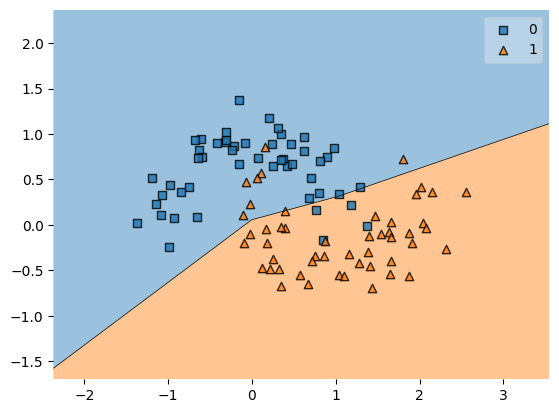

In [31]:
plot_decision_regions(x, y, clf=model2)
plt.show()

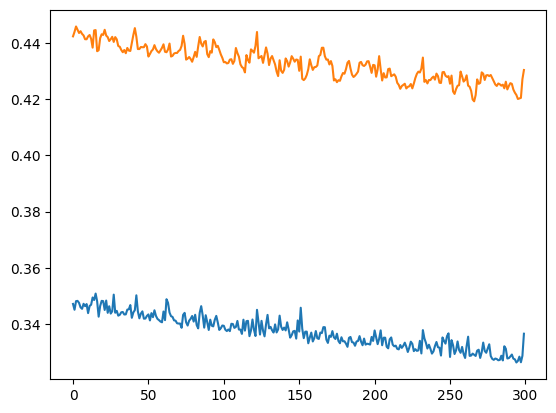

In [32]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.show()

In [35]:
model1_weight_layer = model1.get_weights()[0].reshape(256)
model2_weight_layer = model2.get_weights()[0].reshape(256)

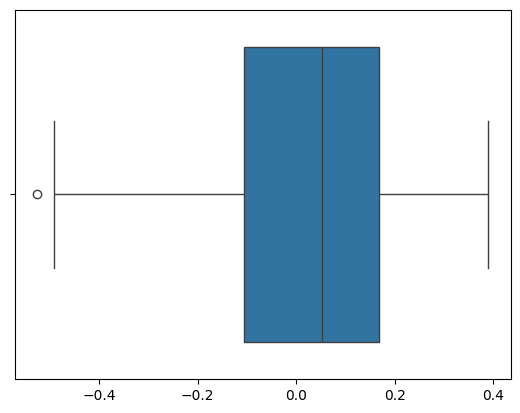

In [38]:
sns.boxplot(x = model1_weight_layer)
plt.show()

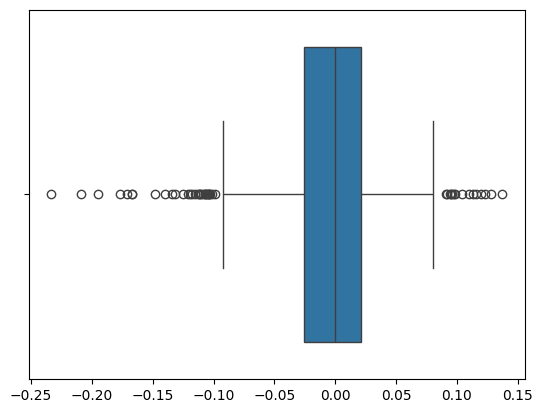

In [39]:
sns.boxplot(x = model2_weight_layer)
plt.show()
#

In [40]:
model1_weight_layer.min()

np.float32(-0.5255433)

In [41]:
model2_weight_layer.min()

np.float32(-0.233508)

In [42]:
model1_weight_layer.max()

np.float32(0.3900613)

In [43]:
model2_weight_layer.max()

np.float32(0.1371197)

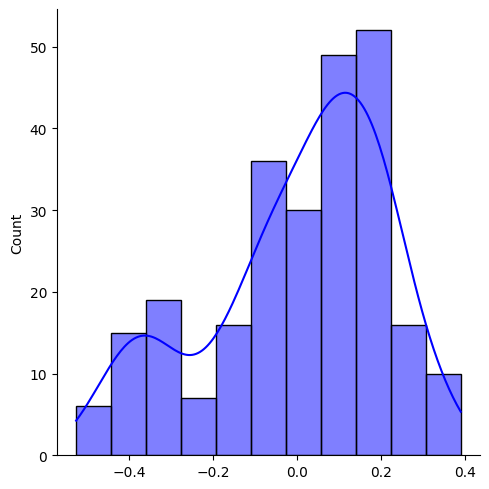

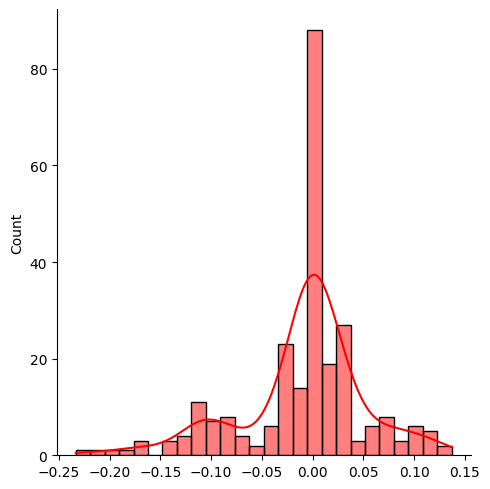

In [55]:
sns.displot( model1_weight_layer, kde=1, color='blue')
sns.displot( model2_weight_layer, kde=1, color='red')
plt.show()
